In [1]:
import pandas as pd

df = pd.read_csv('2019-Nov.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [2]:
smartphone_df = df[df['category_code'] == 'electronics.smartphone'].copy()

In [3]:
#정렬 + unknown처리
df = smartphone_df.sort_values(['user_session', 'event_time']).copy()
df['brand'] = df['brand'].fillna('unknown')

In [4]:
grouped = df.groupby(['user_session', 'brand'])

#grouped = df.groupby(['user_session', 'user_id', 'product_id', 'brand'])

In [5]:
result = []
for (session, brand), group in grouped:
    group = group.sort_values('event_time')  
    events = group['event_type'].tolist()

    
    # index 찾기
    view_idx = next((i for i, e in enumerate(events) if e == 'view'), None)
    cart_idx = next((i for i, e in enumerate(events) if e == 'cart'), None)
    purchase_idx = next((i for i, e in enumerate(events) if e == 'purchase'), None)
    
    has_view = view_idx is not None
    valid_view_cart = view_idx is not None and cart_idx is not None and view_idx < cart_idx
    valid_cart_purchase = cart_idx is not None and purchase_idx is not None and cart_idx < purchase_idx
    
    result.append([
        session, brand,
        has_view,
        valid_view_cart,
        valid_cart_purchase
    ])

funnel_df = pd.DataFrame(result, columns=[
    'user_session', 'brand',
    'view', 'view_to_cart', 'cart_to_purchase'
])

In [6]:
import numpy as np
import pandas as pd

# 브랜드별 퍼널 집계
brand_funnel = (
    funnel_df.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel['view_to_cart_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['view_to_cart_sessions'] / brand_funnel['view_sessions'],
    0
)

brand_funnel['cart_to_purchase_rate'] = np.where(
    brand_funnel['view_to_cart_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_to_cart_sessions'],
    0
)

brand_funnel['total_conversion_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_sessions'],
    0
)

# 이탈률
brand_funnel['drop_view_to_cart'] = 1 - brand_funnel['view_to_cart_rate']
brand_funnel['drop_cart_to_purchase'] = 1 - brand_funnel['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue = (
    smartphone_df[smartphone_df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis = brand_funnel.merge(
    brand_revenue,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis = brand_analysis.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis[rate_cols] = brand_analysis[rate_cols] * 100

brand_analysis.head(20)

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
28,samsung,1682128,263281,123553,15.651663,46.928187,7.345042,84.348337,53.071813,4.271002e+07,161791.0,263.982668
0,apple,1579759,227686,93559,14.412705,41.091240,5.922359,85.587295,58.908760,1.152631e+08,127252.0,905.785903
24,oppo,284529,26553,12063,9.332265,45.429895,4.239638,90.667735,54.570105,3.488541e+06,15080.0,231.335594
37,xiaomi,921407,107108,37784,11.624396,35.276543,4.100685,88.375604,64.723457,9.844621e+06,48553.0,202.760297
11,huawei,420225,39469,17180,9.392349,43.527832,4.088286,90.607651,56.472168,4.550558e+06,21636.0,210.323436
32,tp-link,14679,743,391,5.061653,52.624495,2.663669,94.938347,47.375505,6.596137e+04,560.0,117.788161
36,vivo,55831,3562,1470,6.379968,41.268950,2.632946,93.620032,58.731050,5.161735e+05,1914.0,269.683135
19,meizu,80053,3882,1548,4.849287,39.876352,1.933719,95.150713,60.123648,2.683712e+05,2084.0,128.776972
27,prestigio,7587,334,140,4.402267,41.916168,1.845262,95.597733,58.083832,1.009955e+04,188.0,53.721011
5,fly,1279,37,21,2.892885,56.756757,1.641908,97.107115,43.243243,1.313370e+03,29.0,45.288621


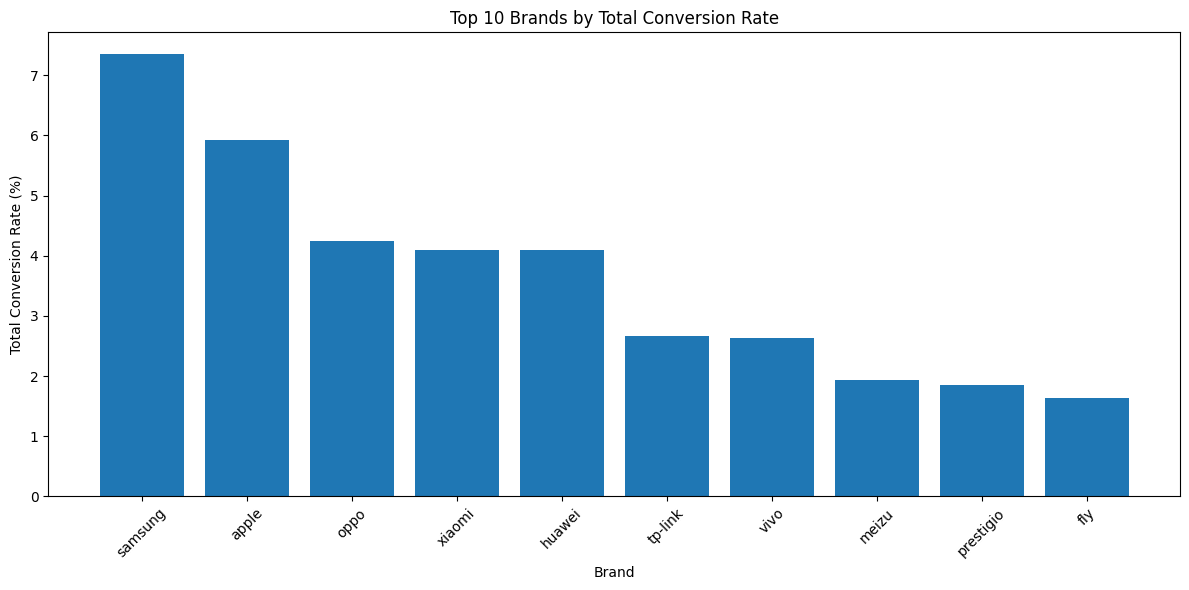

In [7]:
import matplotlib.pyplot as plt

top10_conv = brand_analysis.sort_values(
    by='total_conversion_rate', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_conv['brand'], top10_conv['total_conversion_rate'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Total Conversion Rate')
plt.xlabel('Brand')
plt.ylabel('Total Conversion Rate (%)')
plt.tight_layout()
plt.show()

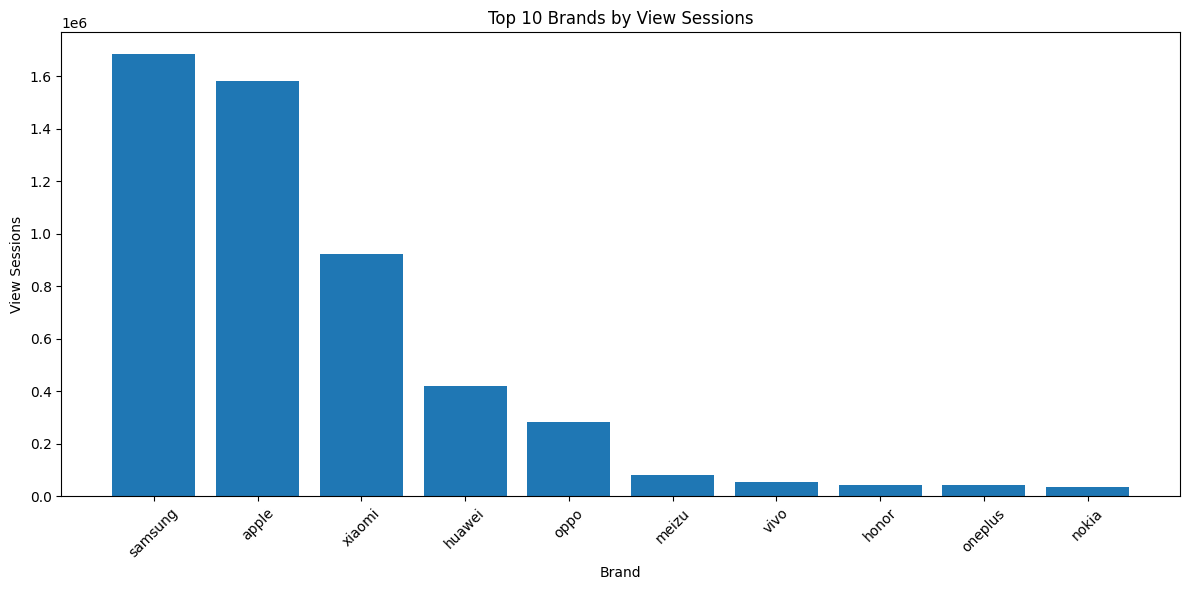

In [8]:
top10_view = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_view['brand'], top10_view['view_sessions'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by View Sessions')
plt.xlabel('Brand')
plt.ylabel('View Sessions')
plt.tight_layout()
plt.show()

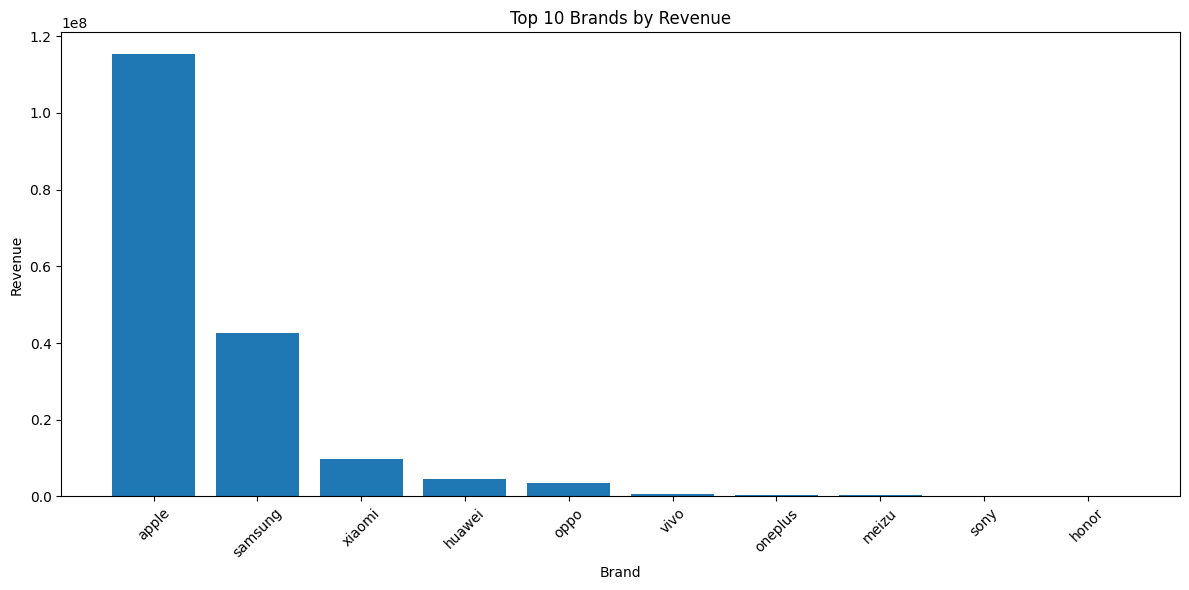

In [9]:
top10_revenue = brand_analysis.sort_values(
    by='revenue', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_revenue['brand'], top10_revenue['revenue'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Revenue')
plt.xlabel('Brand')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

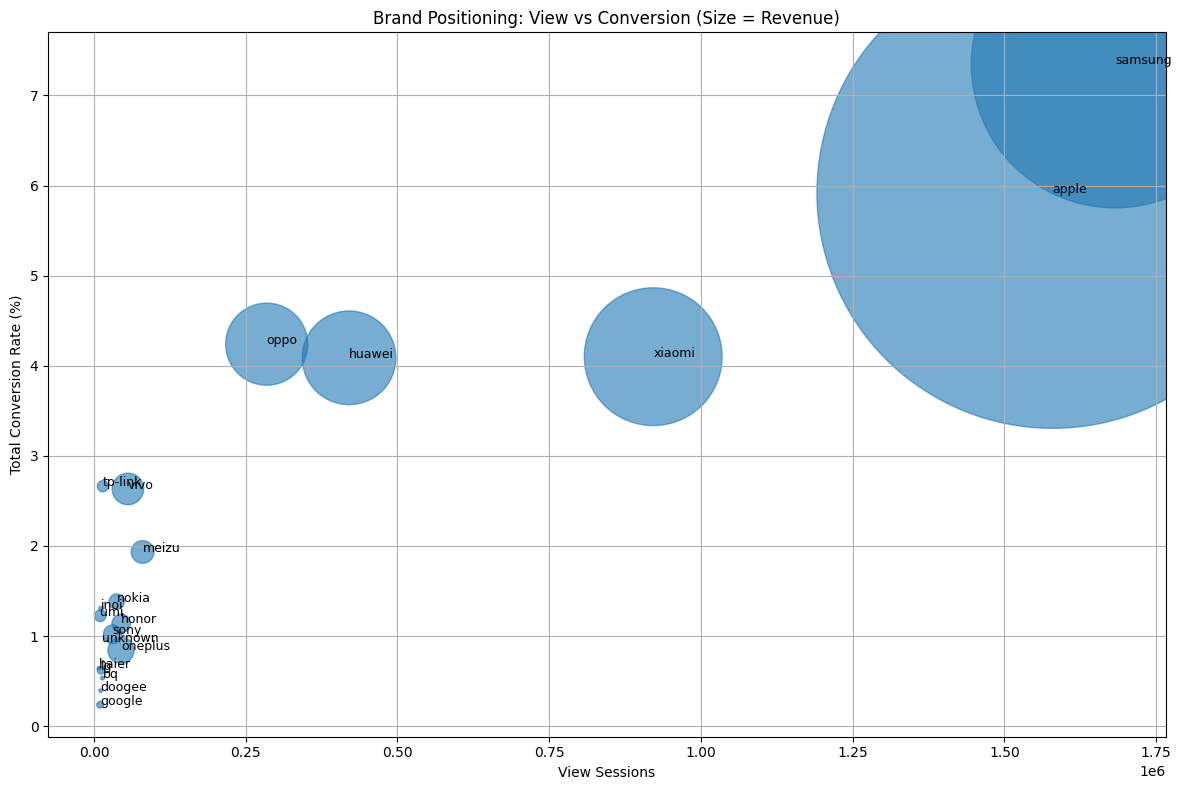

In [10]:
import matplotlib.pyplot as plt

# 상위 브랜드만 (노이즈 제거)
plot_df = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(20).copy()

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_df['view_sessions'],                 # X축: 조회 수
    plot_df['total_conversion_rate'],        # Y축: 전환율
    s=plot_df['revenue'] / 1000,             # 점 크기: 매출 (스케일 조정)
    alpha=0.6
)

# 브랜드 이름 표시
for i, row in plot_df.iterrows():
    plt.text(
        row['view_sessions'],
        row['total_conversion_rate'],
        row['brand'],
        fontsize=9
    )

plt.xlabel('View Sessions')
plt.ylabel('Total Conversion Rate (%)')
plt.title('Brand Positioning: View vs Conversion (Size = Revenue)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
target_brands = ['apple', 'samsung', 'xiaomi']

compare_df = brand_analysis[
    brand_analysis['brand'].str.lower().isin(target_brands)
].copy()

compare_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
28,samsung,1682128,263281,123553,15.651663,46.928187,7.345042,84.348337,53.071813,4.271002e+07,161791.0,263.982668
0,apple,1579759,227686,93559,14.412705,41.091240,5.922359,85.587295,58.908760,1.152631e+08,127252.0,905.785903
37,xiaomi,921407,107108,37784,11.624396,35.276543,4.100685,88.375604,64.723457,9.844621e+06,48553.0,202.760297


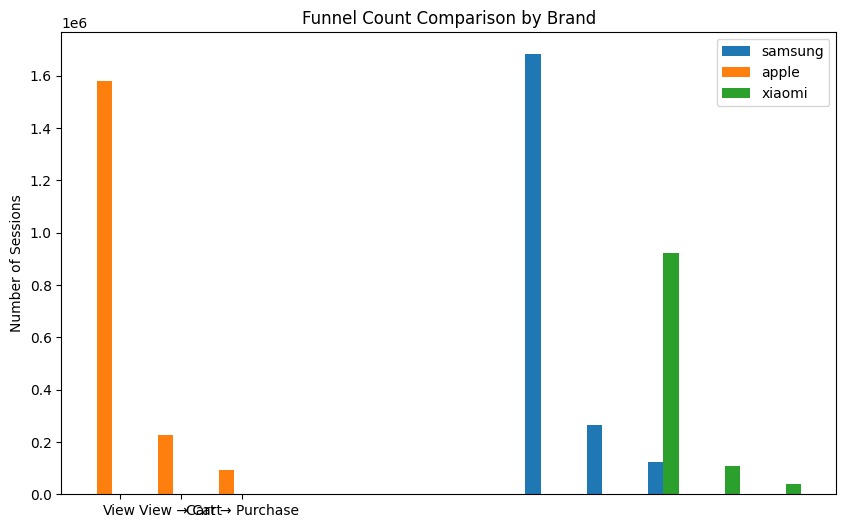

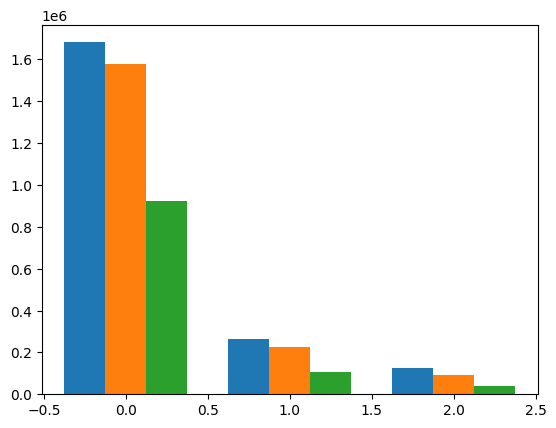

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 퍼널 단계
stages = ['View', 'View → Cart', 'Cart → Purchase']
x = np.arange(len(stages))
width = 0.25

plt.figure(figsize=(10,6))

for i, row in compare_df.iterrows():
    values = [
        row['view_sessions'],
        row['view_to_cart_sessions'],
        row['cart_to_purchase_sessions']
    ]
    
    plt.bar(x + i*width, values, width, label=row['brand'])

# x축 위치 가운데 정렬
plt.xticks(x + width, stages)

plt.ylabel('Number of Sessions')
plt.title('Funnel Count Comparison by Brand')
plt.legend()
plt.show()
for i, row in enumerate(compare_df.itertuples()):
    values = [
        row.view_sessions,
        row.view_to_cart_sessions,
        row.cart_to_purchase_sessions
    ]
    plt.bar(x + (i-1)*width, values, width, label=row.brand)

In [13]:
target_brands = ['apple', 'samsung', 'xiaomi']

df_target = df[df['brand'].str.lower().isin(target_brands)].copy()

2

In [14]:
#2 브랜드별 평균 / 중앙 판매가
brand_price_detail = (
    df_target[df_target['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean'),
        median_price=('price', 'median'),
        min_price=('price', 'min'),
        max_price=('price', 'max')
    )
    .reset_index()
)

brand_price_detail

,brand,purchase_count,avg_price,median_price,min_price,max_price
0,apple,127252,905.785903,915.08,283.12,2053.55
1,samsung,161791,263.982668,196.14,84.86,2562.49
2,xiaomi,48553,202.760297,198.36,66.35,738.76


3

In [15]:
#3. 상위 매출 product_id 비중
#몇 개 주력 모델에 몰려 있는지
product_revenue = (
    df_target[df_target['event_type'] == 'purchase']
    .groupby(['brand', 'product_id'])
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count')
    )
    .reset_index()
)

product_revenue

,brand,product_id,revenue,purchase_count
0,apple,1001618,16554.78,33
1,apple,1001619,706.42,1
2,apple,1002524,3427233.77,6244
3,apple,1002525,365947.09,508
4,apple,1002527,10086.08,14
...,...,...,...,...
445,xiaomi,100014109,9239.11,42
446,xiaomi,100015032,11413.44,52
447,xiaomi,100019218,4648.25,20
448,xiaomi,100020739,701.94,4


In [16]:
#상위 1개 / 3개 / 5개 상품 비중
def top_n_share(group, n):
    return group.sort_values('revenue', ascending=False).head(n)['revenue'].sum() / group['revenue'].sum()

top_share_rows = []

for brand, group in product_revenue.groupby('brand'):
    top_share_rows.append({
        'brand': brand,
        'top1_revenue_share': top_n_share(group, 1),
        'top3_revenue_share': top_n_share(group, 3),
        'top5_revenue_share': top_n_share(group, 5)
    })

top_share_df = pd.DataFrame(top_share_rows)
top_share_df

,brand,top1_revenue_share,top3_revenue_share,top5_revenue_share
0,apple,0.178943,0.339722,0.447463
1,samsung,0.130509,0.297900,0.404150
2,xiaomi,0.140946,0.279085,0.390264


In [17]:
top5_products = (
    product_revenue
    .sort_values(['brand', 'revenue'], ascending=[True, False])
    .groupby('brand')
    .head(5)
)

top5_products

,brand,product_id,revenue,purchase_count
110,apple,1005115,20625574.32,22244
100,apple,1005105,11445354.69,8483
130,apple,1005135,7086522.13,4284
70,apple,1004249,6815294.62,8881
13,apple,1002544,5603193.59,11678
213,samsung,1004767,5574025.06,22613
219,samsung,1004856,4118976.32,32321
223,samsung,1004870,3030325.98,10673
215,samsung,1004833,2310492.29,13486
226,samsung,1004873,2227434.70,6153


4

In [18]:
views_target = df_target[df_target['event_type'] == 'view'].copy()

session_view_depth = (
    views_target.groupby(['brand', 'user_session'])
    .agg(
        view_event_count=('product_id', 'size'),
        unique_view_products=('product_id', 'nunique')
    )
    .reset_index()
)

session_view_depth.head()

,brand,user_session,view_event_count,unique_view_products
0,apple,0000009d-1f5b-40b9-bd23-db4f3d973ae3,1,1
1,apple,00000616-f016-4c01-b323-438486d9d3ee,4,4
2,apple,000009c4-a1dd-4764-87d9-24f3d7e43c4f,4,2
3,apple,000015e0-0fe1-440b-9d4b-1395cef84f38,1,1
4,apple,00001a36-7f5a-4c05-a52b-e9935de5331e,1,1


In [19]:
brand_session_view_depth = (
    session_view_depth.groupby('brand')
    .agg(
        avg_view_events_per_session=('view_event_count', 'mean'),
        median_view_events_per_session=('view_event_count', 'median'),
        avg_unique_products_per_session=('unique_view_products', 'mean'),
        median_unique_products_per_session=('unique_view_products', 'median')
    )
    .reset_index()
)

brand_session_view_depth

,brand,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session
0,apple,2.632933,2.0,1.787492,1.0
1,samsung,2.789960,2.0,1.833448,1.0
2,xiaomi,3.358325,2.0,1.974118,1.0


5

In [20]:
brand_session_compare = (
    views_target.groupby(['brand', 'user_session'])
    .agg(
        unique_models_compared=('product_id', 'nunique')
    )
    .reset_index()
)

brand_session_compare.head()

,brand,user_session,unique_models_compared
0,apple,0000009d-1f5b-40b9-bd23-db4f3d973ae3,1
1,apple,00000616-f016-4c01-b323-438486d9d3ee,4
2,apple,000009c4-a1dd-4764-87d9-24f3d7e43c4f,2
3,apple,000015e0-0fe1-440b-9d4b-1395cef84f38,1
4,apple,00001a36-7f5a-4c05-a52b-e9935de5331e,1


In [21]:
brand_compare_depth = (
    brand_session_compare.groupby('brand')
    .agg(
        avg_model_compare_depth=('unique_models_compared', 'mean'),
        median_model_compare_depth=('unique_models_compared', 'median'),
        max_model_compare_depth=('unique_models_compared', 'max')
    )
    .reset_index()
)

brand_compare_depth

,brand,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth
0,apple,1.787492,1.0,89
1,samsung,1.833448,1.0,49
2,xiaomi,1.974118,1.0,57


In [22]:
compare_ratio = (
    brand_session_compare.groupby('brand')
    .apply(lambda g: pd.Series({
        'compare_2plus_session_ratio': (g['unique_models_compared'] >= 2).mean(),
        'compare_3plus_session_ratio': (g['unique_models_compared'] >= 3).mean()
    }))
    .reset_index()
)

compare_ratio

,brand,compare_2plus_session_ratio,compare_3plus_session_ratio
0,apple,0.360852,0.175248
1,samsung,0.360611,0.185486
2,xiaomi,0.381119,0.208902


In [23]:
brand_compare_depth = brand_compare_depth.merge(
    compare_ratio,
    on='brand',
    how='left'
)

brand_compare_depth

,brand,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,apple,1.787492,1.0,89,0.360852,0.175248
1,samsung,1.833448,1.0,49,0.360611,0.185486
2,xiaomi,1.974118,1.0,57,0.381119,0.208902


In [24]:
final_compare = (
    compare_df
    .merge(
        brand_price_detail[['brand', 'median_price', 'min_price', 'max_price']],
        on='brand',
        how='left'
    )
    .merge(top_share_df, on='brand', how='left')
    .merge(brand_session_view_depth, on='brand', how='left')
    .merge(brand_compare_depth, on='brand', how='left')
)

final_compare

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,...,top5_revenue_share,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,1682128,263281,123553,15.651663,46.928187,7.345042,84.348337,53.071813,4.271002e+07,...,0.404150,2.789960,2.0,1.833448,1.0,1.833448,1.0,49,0.360611,0.185486
1,apple,1579759,227686,93559,14.412705,41.091240,5.922359,85.587295,58.908760,1.152631e+08,...,0.447463,2.632933,2.0,1.787492,1.0,1.787492,1.0,89,0.360852,0.175248
2,xiaomi,921407,107108,37784,11.624396,35.276543,4.100685,88.375604,64.723457,9.844621e+06,...,0.390264,3.358325,2.0,1.974118,1.0,1.974118,1.0,57,0.381119,0.208902


In [25]:
pct_cols = [
    'top1_revenue_share',
    'top3_revenue_share',
    'top5_revenue_share',
    'compare_2plus_session_ratio',
    'compare_3plus_session_ratio'
]

final_compare[pct_cols] = final_compare[pct_cols] * 100

final_compare

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,...,top5_revenue_share,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,1682128,263281,123553,15.651663,46.928187,7.345042,84.348337,53.071813,4.271002e+07,...,40.415000,2.789960,2.0,1.833448,1.0,1.833448,1.0,49,36.061108,18.548648
1,apple,1579759,227686,93559,14.412705,41.091240,5.922359,85.587295,58.908760,1.152631e+08,...,44.746284,2.632933,2.0,1.787492,1.0,1.787492,1.0,89,36.085188,17.524825
2,xiaomi,921407,107108,37784,11.624396,35.276543,4.100685,88.375604,64.723457,9.844621e+06,...,39.026368,3.358325,2.0,1.974118,1.0,1.974118,1.0,57,38.111931,20.890225


시각화

In [26]:
import matplotlib.pyplot as plt
import numpy as np

brand_order = ['samsung', 'apple', 'xiaomi']

plot_df = final_compare.copy()
plot_df['brand'] = pd.Categorical(plot_df['brand'], categories=brand_order, ordered=True)
plot_df = plot_df.sort_values('brand')
plot_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,...,top5_revenue_share,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,1682128,263281,123553,15.651663,46.928187,7.345042,84.348337,53.071813,4.271002e+07,...,40.415000,2.789960,2.0,1.833448,1.0,1.833448,1.0,49,36.061108,18.548648
1,apple,1579759,227686,93559,14.412705,41.091240,5.922359,85.587295,58.908760,1.152631e+08,...,44.746284,2.632933,2.0,1.787492,1.0,1.787492,1.0,89,36.085188,17.524825
2,xiaomi,921407,107108,37784,11.624396,35.276543,4.100685,88.375604,64.723457,9.844621e+06,...,39.026368,3.358325,2.0,1.974118,1.0,1.974118,1.0,57,38.111931,20.890225


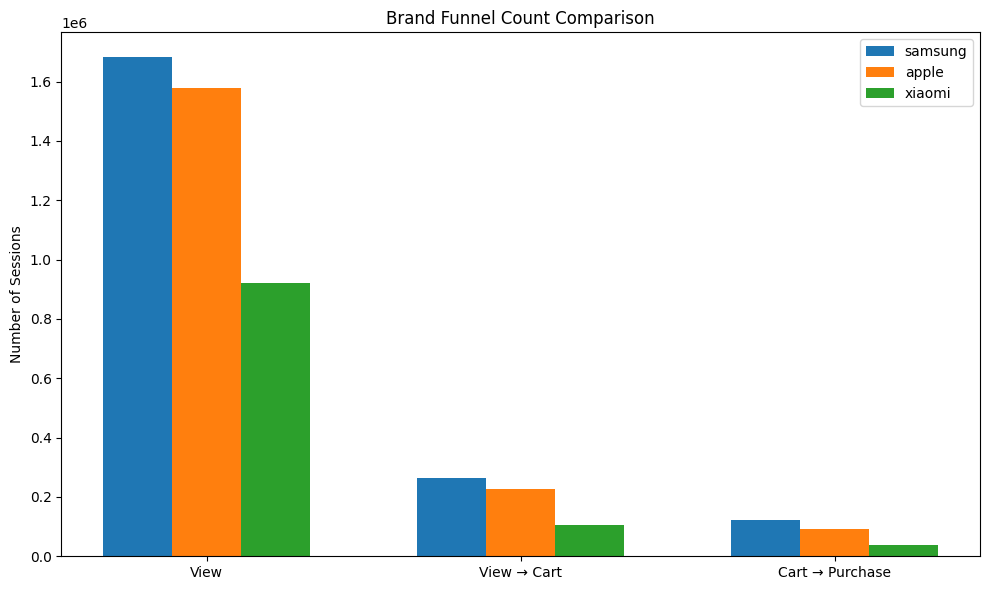

In [27]:
stages = ['View', 'View → Cart', 'Cart → Purchase']
x = np.arange(len(stages))
width = 0.22

plt.figure(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples()):
    values = [
        row.view_sessions,
        row.view_to_cart_sessions,
        row.cart_to_purchase_sessions
    ]
    plt.bar(x + (i - 1) * width, values, width, label=row.brand)

plt.xticks(x, stages)
plt.ylabel('Number of Sessions')
plt.title('Brand Funnel Count Comparison')
plt.legend()
plt.tight_layout()
plt.show()

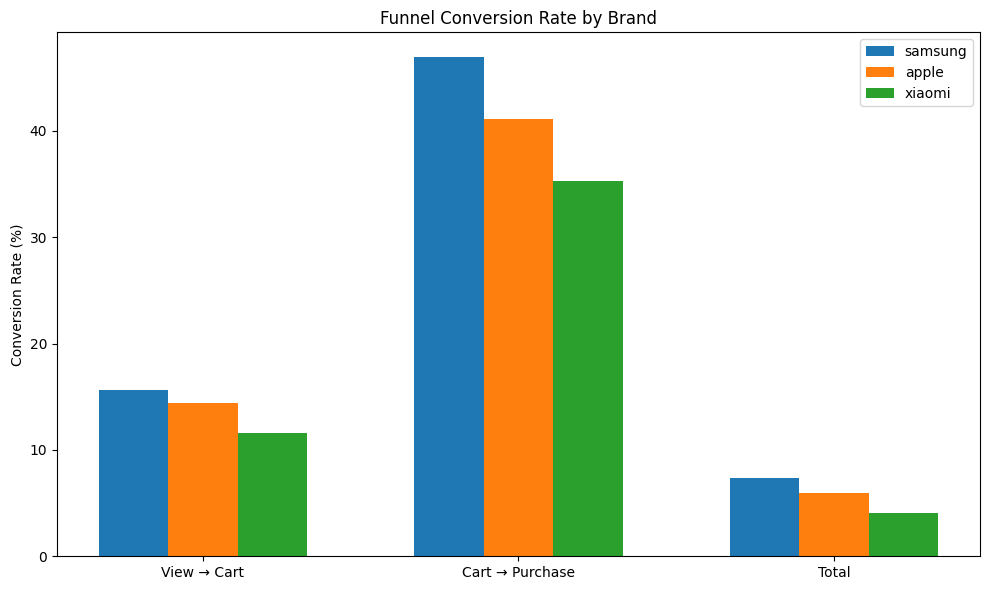

In [28]:
rate_cols = ['view_to_cart_rate', 'cart_to_purchase_rate', 'total_conversion_rate']
rate_labels = ['View → Cart', 'Cart → Purchase', 'Total']

x = np.arange(len(rate_labels))
width = 0.22

plt.figure(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples()):
    values = [row.view_to_cart_rate, row.cart_to_purchase_rate, row.total_conversion_rate]
    plt.bar(x + (i - 1) * width, values, width, label=row.brand)

plt.xticks(x, rate_labels)
plt.ylabel('Conversion Rate (%)')
plt.title('Funnel Conversion Rate by Brand')
plt.legend()
plt.tight_layout()
plt.show()

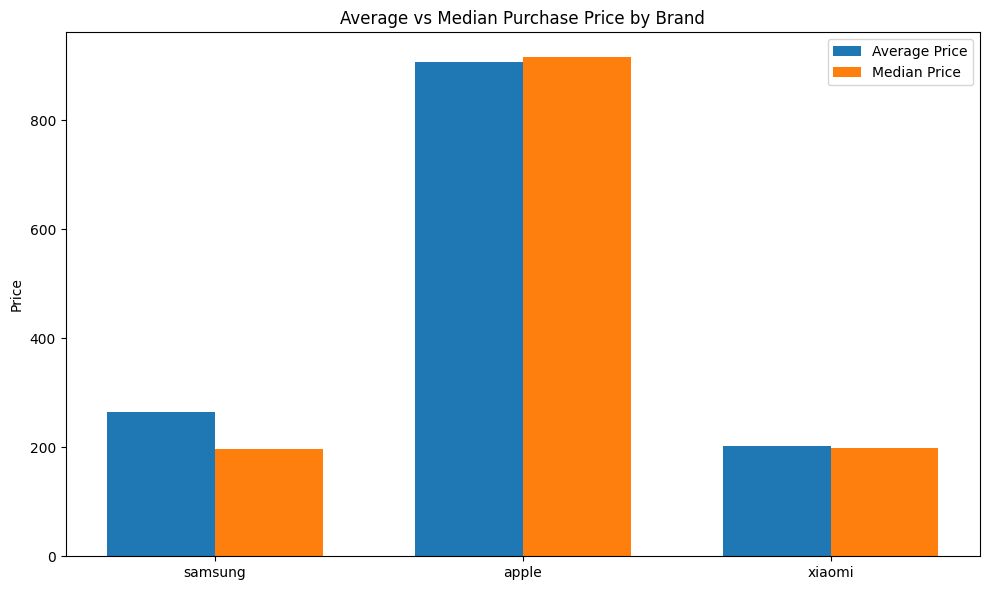

In [29]:
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df['avg_price'], width, label='Average Price')
plt.bar(x + width/2, plot_df['median_price'], width, label='Median Price')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Price')
plt.title('Average vs Median Purchase Price by Brand')
plt.legend()
plt.tight_layout()
plt.show()

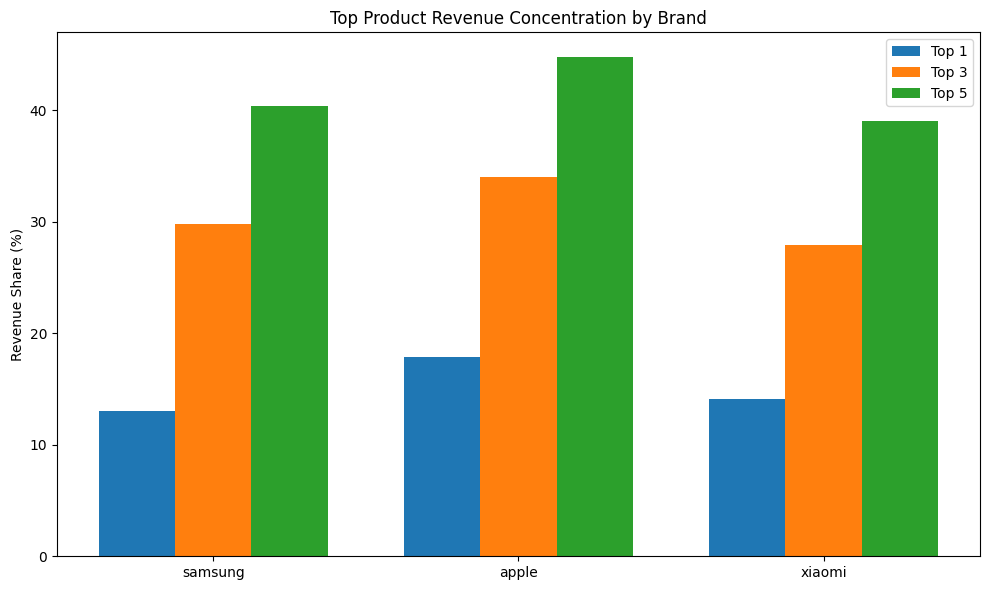

In [30]:
x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, plot_df['top1_revenue_share'], width, label='Top 1')
plt.bar(x, plot_df['top3_revenue_share'], width, label='Top 3')
plt.bar(x + width, plot_df['top5_revenue_share'], width, label='Top 5')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Revenue Share (%)')
plt.title('Top Product Revenue Concentration by Brand')
plt.legend()
plt.tight_layout()
plt.show()

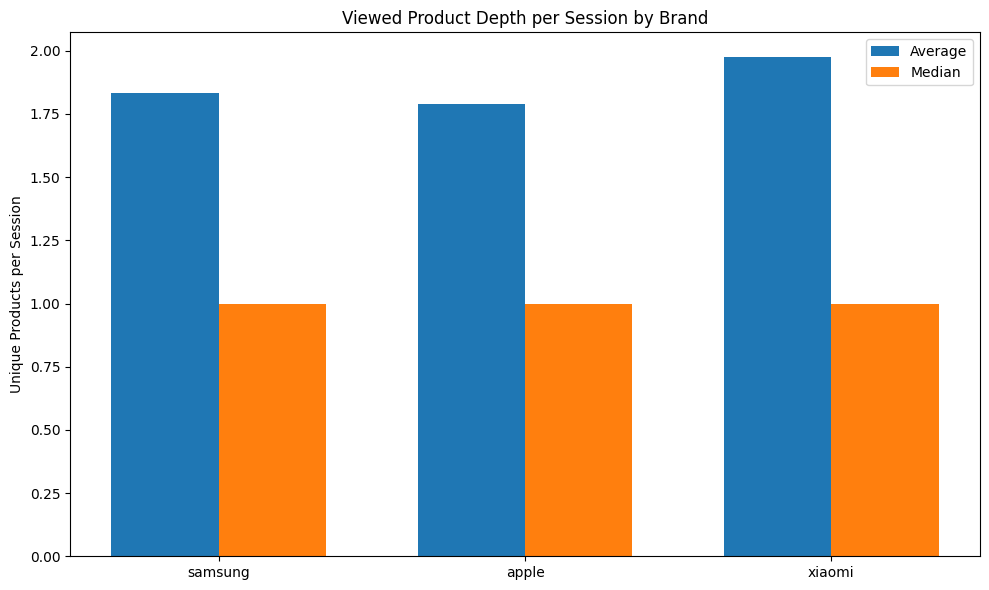

In [31]:
#세션 당 조회 상품 수
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df['avg_unique_products_per_session'], width, label='Average')
plt.bar(x + width/2, plot_df['median_unique_products_per_session'], width, label='Median')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Unique Products per Session')
plt.title('Viewed Product Depth per Session by Brand')
plt.legend()
plt.tight_layout()
plt.show()